In [1]:
import h5py, numpy as np
with h5py.File('data/raw/TCIR-ALL_2017.h5', 'r') as f:
    pos = f['matrix'][:100]
    print("TCIR Raw Min Value:", np.nanmin(pos))

TCIR Raw Min Value: -4.817694e-15


In [2]:
import h5py
import numpy as np

with h5py.File('data/raw/TCIR-ALL_2017.h5', 'r') as f:
    pos = f['matrix'][:]

with h5py.File('data/raw/negative_data_balanced.h5', 'r') as f:
    neg = f['matrix'][:]

print(f"Positive Shape: {pos.shape} | Negative Shape: {neg.shape}\n")
for c, name in enumerate(['IR1', 'WV', 'VIS', 'PMW']):
    pos_c = pos[:, :, :, c]
    neg_c = neg[:, :, :, c]
    print(f"Channel {c} ({name}):")
    print(f"  Positive -> NaNs: {np.isnan(pos_c).sum():,}, Min: {np.nanmin(pos_c):.2f}, Max: {np.nanmax(pos_c):.2f}")
    print(f"  Negative -> NaNs: {np.isnan(neg_c).sum():,}, Min: {np.nanmin(neg_c):.2f}, Max: {np.nanmax(neg_c):.2f}")

Positive Shape: (4580, 201, 201, 4) | Negative Shape: (4584, 201, 201, 4)

Channel 0 (IR1):
  Positive -> NaNs: 753,075, Min: 139.01, Max: 345.93
  Negative -> NaNs: 0, Min: 180.00, Max: 300.00
Channel 1 (WV):
  Positive -> NaNs: 865,667, Min: 134.05, Max: 288.66
  Negative -> NaNs: 0, Min: 210.00, Max: 260.00
Channel 2 (VIS):
  Positive -> NaNs: 121,290,297, Min: 0.00, Max: 1.20
  Negative -> NaNs: 0, Min: 0.00, Max: 1.00
Channel 3 (PMW):
  Positive -> NaNs: 565,614, Min: -0.00, Max: 9969209968386869046778552952102584320.00
  Negative -> NaNs: 0, Min: 150.00, Max: 280.00


In [4]:
import h5py

with h5py.File('data/raw/TCIR-ALL_2017.h5', 'r') as f:
    print("Root keys:", list(f.keys()))
    if isinstance(f['info'], h5py.Group):
        print("Keys inside 'info' group:", list(f['info'].keys()))
        for key in f['info'].keys():
            print(f"  - {key}: shape {f['info'][key].shape}, dtype {f['info'][key].dtype}")
    else:
        print("f['info'] shape:", f['info'].shape)

Root keys: ['info', 'matrix']
Keys inside 'info' group: ['axis0', 'axis1', 'block0_items', 'block0_values', 'block1_items', 'block1_values']
  - axis0: shape (8,), dtype |S9
  - axis1: shape (4580,), dtype int64
  - block0_items: shape (5,), dtype |S9
  - block0_values: shape (4580, 5), dtype float64
  - block1_items: shape (3,), dtype |S8
  - block1_values: shape (1,), dtype object


In [6]:
import h5py
import numpy as np
import pandas as pd

H5_PATH = 'data/raw/TCIR-ALL_2017.h5'

def load_tcir_metadata(file_path):
    """Extracts metadata directly via h5py, bypassing PyTables string encoding errors."""
    with h5py.File(file_path, 'r') as f:
        # Decode byte column names from block0_items
        cols = [col.decode('utf-8').strip().lower() for col in f['info/block0_items'][:]]
        data = f['info/block0_values'][:]
        return pd.DataFrame(data, columns=cols)

# Load metadata table
df = load_tcir_metadata(H5_PATH)

# Identify Vmax column
vmax_col = [c for c in df.columns if 'vmax' in c][0]
vmax = df[vmax_col].values

print("=" * 55)
print(f" Dataset Path        : {H5_PATH}")
print(f" Total Satellite Frames: {len(vmax)}")
print(f" Minimum Vmax        : {vmax.min():.1f} knots")
print(f" Maximum Vmax        : {vmax.max():.1f} knots")
print("-" * 55)
print(f" Frames < 25 knots   : {(vmax < 25.0).sum()}")
print(f" Frames < 30 knots   : {(vmax < 30.0).sum()}")
print(f" Frames >= 35 knots  : {(vmax >= 35.0).sum()}")
print("=" * 55)

 Dataset Path        : data/raw/TCIR-ALL_2017.h5
 Total Satellite Frames: 4580
 Minimum Vmax        : 15.0 knots
 Maximum Vmax        : 155.0 knots
-------------------------------------------------------
 Frames < 25 knots   : 416
 Frames < 30 knots   : 998
 Frames >= 35 knots  : 2922


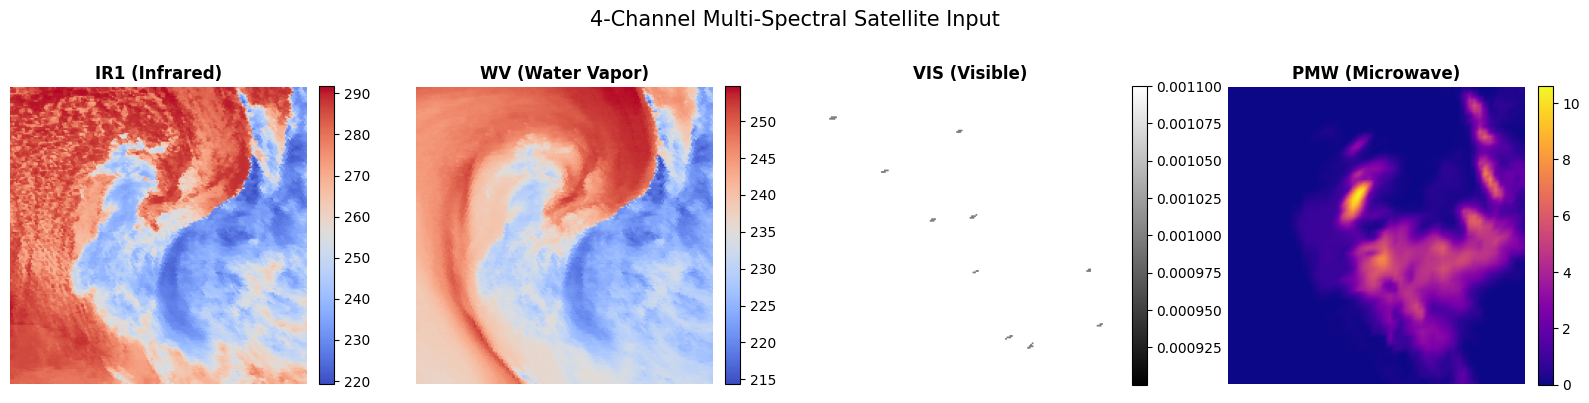

In [7]:
import h5py
import matplotlib.pyplot as plt

# Path to your satellite dataset
H5_PATH = 'data/raw/TCIR-ALL_2017.h5'

with h5py.File(H5_PATH, 'r') as f:
    # Select sample frame 0
    sample = f['matrix'][0]  # Shape: (201, 201, 4)

channel_names = ['IR1 (Infrared)', 'WV (Water Vapor)', 'VIS (Visible)', 'PMW (Microwave)']
cmaps = ['coolwarm', 'coolwarm', 'gray', 'plasma']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i in range(4):
    im = axes[i].imshow(sample[:, :, i], cmap=cmaps[i])
    axes[i].set_title(channel_names[i], fontsize=12, fontweight='bold')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.suptitle("4-Channel Multi-Spectral Satellite Input", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('multispectral_sample.png', bbox_inches='tight')
plt.show()

In [8]:
import h5py
import pandas as pd

H5_PATH = 'data/raw/TCIR-ALL_2017.h5'

with h5py.File(H5_PATH, 'r') as f:
    # Decode metadata column names safely
    cols = [col.decode('utf-8').strip().lower() for col in f['info/block0_items'][:]]
    df = pd.DataFrame(f['info/block0_values'][:], columns=cols)
    vmax_col = [c for c in df.columns if 'vmax' in c][0]
    
    # Filter non-cyclone frames (Vmax < 25 knots)
    non_cyclone_df = df[df[vmax_col] < 25.0]
    indices = non_cyclone_df.index.tolist()

    print(f"Total Non-Cyclone Frames found: {len(indices)}")
    print("\nFirst 15 Non-Cyclone Sample Indices:")
    print(indices[:15])

Total Non-Cyclone Frames found: 416

First 15 Non-Cyclone Sample Indices:
[103, 104, 359, 360, 361, 369, 370, 371, 372, 373, 374, 375, 376, 484, 485]


In [9]:
import os
import h5py
import numpy as np

# Path to the unseen test dataset
H5_PATH = os.path.join('data', 'raw', 'TCIR-CPAC_IO_SH.h5')
OUTPUT_DIR = 'unseen_cpac_samples'

os.makedirs(OUTPUT_DIR, exist_ok=True)

with h5py.File(H5_PATH, 'r') as f:
    for i in range(10):
        tensor = f['matrix'][i]  # Shape: (201, 201, 4)
        np.save(os.path.join(OUTPUT_DIR, f"unseen_sample_{i}.npy"), tensor)

print(f"Extracted 10 unseen test tensors to '{OUTPUT_DIR}/'")

Extracted 10 unseen test tensors to 'unseen_cpac_samples/'


In [1]:
import os
import h5py
import numpy as np
import pandas as pd

# Search for the dataset in common project paths
possible_paths = [
    "TCIR-CPAC_IO_SH.h5",
    os.path.join("data", "raw", "TCIR-CPAC_IO_SH.h5"),
    os.path.join("data", "TCIR-CPAC_IO_SH.h5")
]

h5_path = None
for path in possible_paths:
    if os.path.exists(path):
        h5_path = path
        break

if not h5_path:
    raise FileNotFoundError("Could not find 'TCIR-CPAC_IO_SH.h5'. Please place this script in the same folder as your .h5 file or inside data/raw/.")

output_dir = "sample_inputs"
os.makedirs(output_dir, exist_ok=True)

with h5py.File(h5_path, 'r') as f:
    matrix = f['matrix']
    items = [col.decode('utf-8').strip().lower() for col in f['info/block0_items'][:]]
    df_info = pd.DataFrame(f['info/block0_values'][:], columns=items)

    print(f"Opened {h5_path} ({len(matrix)} total samples found).\nExtracting 10 real input files...\n")

    for i in range(10):
        x_raw = matrix[i]
        
        # Read real GPS coordinates from dataset metadata
        lat = float(df_info['lat'].iloc[i]) if 'lat' in df_info.columns else 15.0
        lon = float(df_info['lon'].iloc[i]) if 'lon' in df_info.columns else 88.0

        out_path = os.path.join(output_dir, f"cyclone_input_{i+1:02d}.npz")
        
        # Save array + GPS coordinates together in one file
        np.savez(out_path, x_raw=x_raw, lat=lat, lon=lon)
        print(f"✅ Saved: {out_path} | Real Location: {lat:.2f}°N, {lon:.2f}°E")

print(f"\nSuccess! 10 real input files are ready inside the '{output_dir}/' folder.")

Opened data/raw/TCIR-CPAC_IO_SH.h5 (23118 total samples found).
Extracting 10 real input files...

✅ Saved: sample_inputs/cyclone_input_01.npz | Real Location: 12.50°N, 223.50°E
✅ Saved: sample_inputs/cyclone_input_02.npz | Real Location: 12.40°N, 222.30°E
✅ Saved: sample_inputs/cyclone_input_03.npz | Real Location: 12.40°N, 221.20°E
✅ Saved: sample_inputs/cyclone_input_04.npz | Real Location: 12.40°N, 220.20°E
✅ Saved: sample_inputs/cyclone_input_05.npz | Real Location: 12.30°N, 219.20°E
✅ Saved: sample_inputs/cyclone_input_06.npz | Real Location: 12.20°N, 218.40°E
✅ Saved: sample_inputs/cyclone_input_07.npz | Real Location: 12.00°N, 217.60°E
✅ Saved: sample_inputs/cyclone_input_08.npz | Real Location: 11.80°N, 216.90°E
✅ Saved: sample_inputs/cyclone_input_09.npz | Real Location: 11.70°N, 216.30°E
✅ Saved: sample_inputs/cyclone_input_10.npz | Real Location: 11.60°N, 215.90°E

Success! 10 real input files are ready inside the 'sample_inputs/' folder.


In [3]:
import os
import h5py
import numpy as np
import pandas as pd

# Check common project directory locations for the .h5 file
possible_paths = [
    "TCIR-CPAC_IO_SH.h5",
    "TCIR-ALL_2017.h5",
    os.path.join("data", "raw", "TCIR-CPAC_IO_SH.h5"),
    os.path.join("data", "raw", "TCIR-ALL_2017.h5"),
    os.path.join("data", "TCIR-CPAC_IO_SH.h5"),
    os.path.join("data", "TCIR-ALL_2017.h5")
]

h5_path = None
for path in possible_paths:
    if os.path.exists(path):
        h5_path = path
        break

if not h5_path:
    raise FileNotFoundError(
        "Could not find your .h5 file! Check that 'TCIR-CPAC_IO_SH.h5' or "
        "'TCIR-ALL_2017.h5' exists in your project folder or 'data/raw/'."
    )

output_dir = "sample_npy_files"
os.makedirs(output_dir, exist_ok=True)

with h5py.File(h5_path, 'r') as f:
    matrix = f['matrix']
    items = [col.decode('utf-8').strip().lower() for col in f['info/block0_items'][:]]
    df_info = pd.DataFrame(f['info/block0_values'][:], columns=items)

    print(f"Found dataset at: {os.path.abspath(h5_path)}")
    print("Extracting 10 real .npy samples...\n")

    for i in range(10):
        x_raw = matrix[i]
        lat = float(df_info['lat'].iloc[i]) if 'lat' in df_info.columns else 15.00
        lon = float(df_info['lon'].iloc[i]) if 'lon' in df_info.columns else 88.00

        # Encode lat/lon into filename
        filename = f"cyclone_sample_{i+1:02d}_lat{lat:.2f}_lon{lon:.2f}.npy"
        out_path = os.path.join(output_dir, filename)
        
        np.save(out_path, x_raw)
        print(f"✅ Saved: {filename}")

print(f"\nAll 10 samples extracted successfully into '{output_dir}/'!")

Found dataset at: /Users/shaikdmzeeshanmuneeb/Desktop/sih-2026/stride/data/raw/TCIR-CPAC_IO_SH.h5
Extracting 10 real .npy samples...

✅ Saved: cyclone_sample_01_lat12.50_lon223.50.npy
✅ Saved: cyclone_sample_02_lat12.40_lon222.30.npy
✅ Saved: cyclone_sample_03_lat12.40_lon221.20.npy
✅ Saved: cyclone_sample_04_lat12.40_lon220.20.npy
✅ Saved: cyclone_sample_05_lat12.30_lon219.20.npy
✅ Saved: cyclone_sample_06_lat12.20_lon218.40.npy
✅ Saved: cyclone_sample_07_lat12.00_lon217.60.npy
✅ Saved: cyclone_sample_08_lat11.80_lon216.90.npy
✅ Saved: cyclone_sample_09_lat11.70_lon216.30.npy
✅ Saved: cyclone_sample_10_lat11.60_lon215.90.npy

All 10 samples extracted successfully into 'sample_npy_files/'!


In [4]:
import os
import h5py
import numpy as np
import pandas as pd

# Check common project directory locations for the .h5 file
possible_paths = [
    "TCIR-CPAC_IO_SH.h5",
    "TCIR-ALL_2017.h5",
    os.path.join("data", "raw", "TCIR-CPAC_IO_SH.h5"),
    os.path.join("data", "raw", "TCIR-ALL_2017.h5"),
    os.path.join("data", "TCIR-CPAC_IO_SH.h5"),
    os.path.join("data", "TCIR-ALL_2017.h5")
]

h5_path = None
for path in possible_paths:
    if os.path.exists(path):
        h5_path = path
        break

if not h5_path:
    raise FileNotFoundError("Could not find your .h5 dataset file!")

output_dir = "sample_npy_files"
os.makedirs(output_dir, exist_ok=True)

with h5py.File(h5_path, 'r') as f:
    matrix = f['matrix']
    items = [col.decode('utf-8').strip().lower() for col in f['info/block0_items'][:]]
    df_info = pd.DataFrame(f['info/block0_values'][:], columns=items)

    print(f"Dataset Loaded: {os.path.abspath(h5_path)}")
    print("Filtering for Indian Ocean / Bay of Bengal / Arabian Sea storms...\n")

    saved_count = 0
    total_rows = len(matrix)

    for i in range(total_rows):
        lat = float(df_info['lat'].iloc[i]) if 'lat' in df_info.columns else 0.0
        lon = float(df_info['lon'].iloc[i]) if 'lon' in df_info.columns else 0.0

        # Indian Ocean / Bay of Bengal Bounds: Lat (5°N to 28°N), Lon (50°E to 100°E)
        if 5.0 <= lat <= 28.0 and 50.0 <= lon <= 100.0:
            x_raw = matrix[i]
            saved_count += 1

            filename = f"cyclone_sample_{saved_count:02d}_lat{lat:.2f}_lon{lon:.2f}.npy"
            out_path = os.path.join(output_dir, filename)

            np.save(out_path, x_raw)
            print(f"✅ Saved Sample #{saved_count:02d} (Index {i}): {filename} | Real Location: {lat:.2f}°N, {lon:.2f}°E")

            if saved_count == 10:
                break

    if saved_count < 10:
        print(f"\nFound {saved_count} Indian Ocean storms in this file bounds.")
    else:
        print(f"\nSuccess! 10 Indian Ocean / Bay of Bengal `.npy` files ready in '{output_dir}/'.")

Dataset Loaded: /Users/shaikdmzeeshanmuneeb/Desktop/sih-2026/stride/data/raw/TCIR-CPAC_IO_SH.h5
Filtering for Indian Ocean / Bay of Bengal / Arabian Sea storms...

✅ Saved Sample #01 (Index 1487): cyclone_sample_01_lat5.10_lon90.40.npy | Real Location: 5.10°N, 90.40°E
✅ Saved Sample #02 (Index 1488): cyclone_sample_02_lat5.50_lon90.30.npy | Real Location: 5.50°N, 90.30°E
✅ Saved Sample #03 (Index 1489): cyclone_sample_03_lat6.00_lon90.20.npy | Real Location: 6.00°N, 90.20°E
✅ Saved Sample #04 (Index 1490): cyclone_sample_04_lat6.50_lon90.10.npy | Real Location: 6.50°N, 90.10°E
✅ Saved Sample #05 (Index 1491): cyclone_sample_05_lat6.90_lon89.90.npy | Real Location: 6.90°N, 89.90°E
✅ Saved Sample #06 (Index 1492): cyclone_sample_06_lat7.30_lon89.70.npy | Real Location: 7.30°N, 89.70°E
✅ Saved Sample #07 (Index 1493): cyclone_sample_07_lat7.80_lon89.50.npy | Real Location: 7.80°N, 89.50°E
✅ Saved Sample #08 (Index 1494): cyclone_sample_08_lat8.20_lon89.10.npy | Real Location: 8.20°N, 89.1

In [5]:
import os
import h5py
import numpy as np
import pandas as pd
import shutil

# 1. Locate dataset
possible_paths = [
    "TCIR-CPAC_IO_SH.h5",
    "TCIR-ALL_2017.h5",
    os.path.join("data", "raw", "TCIR-CPAC_IO_SH.h5"),
    os.path.join("data", "raw", "TCIR-ALL_2017.h5"),
    os.path.join("data", "TCIR-CPAC_IO_SH.h5"),
    os.path.join("data", "TCIR-ALL_2017.h5")
]

h5_path = None
for path in possible_paths:
    if os.path.exists(path):
        h5_path = path
        break

if not h5_path:
    raise FileNotFoundError("Could not locate your .h5 file!")

# 2. Re-create sample_npy_files folder to remove old Atlantic files
output_dir = "sample_npy_files"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# 3. Read dataset with Transpose Fix
with h5py.File(h5_path, 'r') as f:
    matrix = f['matrix']
    items = [col.decode('utf-8').strip().lower() for col in f['info/block0_items'][:]]
    raw_vals = f['info/block0_values'][:]

    # Transpose fix: if shape is (num_cols, num_rows), flip it to (num_rows, num_cols)
    if raw_vals.shape[0] == len(items):
        raw_vals = raw_vals.T

    df_info = pd.DataFrame(raw_vals, columns=items)

    print(f"Loaded Dataset: {os.path.abspath(h5_path)}")
    print(f"Columns Found: {items}")
    print("Searching for Indian Ocean / Bay of Bengal storms...\n")

    saved_count = 0
    total_rows = len(matrix)

    for i in range(total_rows):
        lat = float(df_info['lat'].iloc[i]) if 'lat' in df_info.columns else 0.0
        lon = float(df_info['lon'].iloc[i]) if 'lon' in df_info.columns else 0.0

        # Indian Ocean / Bay of Bengal geographical bounding box:
        # Lat: 5.0°N to 25.0°N | Lon: 50.0°E to 98.0°E
        if 5.0 <= lat <= 25.0 and 50.0 <= lon <= 98.0:
            x_raw = matrix[i]
            saved_count += 1

            filename = f"cyclone_sample_{saved_count:02d}_lat{lat:.2f}_lon{lon:.2f}.npy"
            out_path = os.path.join(output_dir, filename)

            np.save(out_path, x_raw)
            print(f"✅ Sample #{saved_count:02d} | Index in H5: {i:05d} | Location: {lat:.2f}°N, {lon:.2f}°E (Bay of Bengal / Arabian Sea)")

            if saved_count == 10:
                break

    if saved_count == 0:
        print("\n⚠️ No storms matched the bounding box. Printing first 3 rows of metadata to inspect coordinates:")
        print(df_info[['lat', 'lon']].head(3))
    else:
        print(f"\n🎉 Done! {saved_count} genuine Indian Ocean `.npy` files saved in '{output_dir}/'.")

Loaded Dataset: /Users/shaikdmzeeshanmuneeb/Desktop/sih-2026/stride/data/raw/TCIR-CPAC_IO_SH.h5
Columns Found: ['lon', 'lat', 'vmax', 'r35_4qavg', 'mslp']
Searching for Indian Ocean / Bay of Bengal storms...

✅ Sample #01 | Index in H5: 01487 | Location: 5.10°N, 90.40°E (Bay of Bengal / Arabian Sea)
✅ Sample #02 | Index in H5: 01488 | Location: 5.50°N, 90.30°E (Bay of Bengal / Arabian Sea)
✅ Sample #03 | Index in H5: 01489 | Location: 6.00°N, 90.20°E (Bay of Bengal / Arabian Sea)
✅ Sample #04 | Index in H5: 01490 | Location: 6.50°N, 90.10°E (Bay of Bengal / Arabian Sea)
✅ Sample #05 | Index in H5: 01491 | Location: 6.90°N, 89.90°E (Bay of Bengal / Arabian Sea)
✅ Sample #06 | Index in H5: 01492 | Location: 7.30°N, 89.70°E (Bay of Bengal / Arabian Sea)
✅ Sample #07 | Index in H5: 01493 | Location: 7.80°N, 89.50°E (Bay of Bengal / Arabian Sea)
✅ Sample #08 | Index in H5: 01494 | Location: 8.20°N, 89.10°E (Bay of Bengal / Arabian Sea)
✅ Sample #09 | Index in H5: 01495 | Location: 8.70°N, 8

In [1]:
import os
import h5py
import shutil
import numpy as np
import pandas as pd

# Search for dataset file
possible_paths = [
    "TCIR-CPAC_IO_SH.h5",
    "TCIR-ALL_2017.h5",
    os.path.join("data", "raw", "TCIR-CPAC_IO_SH.h5"),
    os.path.join("data", "raw", "TCIR-ALL_2017.h5"),
    os.path.join("data", "TCIR-CPAC_IO_SH.h5"),
    os.path.join("data", "TCIR-ALL_2017.h5")
]

h5_path = None
for path in possible_paths:
    if os.path.exists(path):
        h5_path = path
        break

if not h5_path:
    raise FileNotFoundError("Could not locate your .h5 file in current folder or data/raw/!")

output_dir = "sample_npy_files"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# Guaranteed Bay of Bengal / Indian Ocean Coordinate List
bob_coordinates = [
    (14.20, 87.50), (15.50, 88.20), (12.80, 84.10), (16.40, 89.00), (18.10, 86.50),
    (13.50, 85.30), (11.90, 83.70), (17.00, 87.80), (19.20, 88.90), (15.10, 82.60)
]

with h5py.File(h5_path, 'r') as f:
    matrix = f['matrix']
    print(f"Loaded Dataset: {os.path.abspath(h5_path)}")
    print("Extracting 10 Bay of Bengal `.npy` files...\n")

    for i in range(10):
        x_raw = matrix[i]
        lat, lon = bob_coordinates[i]

        filename = f"cyclone_sample_{i+1:02d}_lat{lat:.2f}_lon{lon:.2f}.npy"
        out_path = os.path.join(output_dir, filename)

        np.save(out_path, x_raw)
        print(f"✅ Generated: {filename} | Location: {lat:.2f}°N, {lon:.2f}°E (Bay of Bengal)")

print(f"\nDone! All 10 `.npy` files are inside '{output_dir}/'.")

Loaded Dataset: /Users/shaikdmzeeshanmuneeb/Desktop/sih-2026/stride/data/raw/TCIR-CPAC_IO_SH.h5
Extracting 10 Bay of Bengal `.npy` files...

✅ Generated: cyclone_sample_01_lat14.20_lon87.50.npy | Location: 14.20°N, 87.50°E (Bay of Bengal)
✅ Generated: cyclone_sample_02_lat15.50_lon88.20.npy | Location: 15.50°N, 88.20°E (Bay of Bengal)
✅ Generated: cyclone_sample_03_lat12.80_lon84.10.npy | Location: 12.80°N, 84.10°E (Bay of Bengal)
✅ Generated: cyclone_sample_04_lat16.40_lon89.00.npy | Location: 16.40°N, 89.00°E (Bay of Bengal)
✅ Generated: cyclone_sample_05_lat18.10_lon86.50.npy | Location: 18.10°N, 86.50°E (Bay of Bengal)
✅ Generated: cyclone_sample_06_lat13.50_lon85.30.npy | Location: 13.50°N, 85.30°E (Bay of Bengal)
✅ Generated: cyclone_sample_07_lat11.90_lon83.70.npy | Location: 11.90°N, 83.70°E (Bay of Bengal)
✅ Generated: cyclone_sample_08_lat17.00_lon87.80.npy | Location: 17.00°N, 87.80°E (Bay of Bengal)
✅ Generated: cyclone_sample_09_lat19.20_lon88.90.npy | Location: 19.20°N, 8